In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the data
df_merged = pd.read_csv('merged_dataset.csv')
df_desc = pd.read_csv('desc.csv')

# Merge datasets based on filename
df = pd.merge(df_merged, df_desc, on='filename', how='inner')

# Filter for train and valid splits (ignore 'test')
df = df[df['split'].isin(['train', 'valid'])].copy()

# Fill missing text values
df['text'] = df['text'].fillna('').astype(str)
df['desc'] = df['desc'].fillna('').astype(str)
df['label'] = df['label'].astype(int)

# Separate the splits
train_df = df[df['split'] == 'train']
valid_df = df[df['split'] == 'valid']

print(f"Dataset ready: {len(train_df)} training and {len(valid_df)} validation samples.")

Dataset ready: 8500 training and 500 validation samples.


In [2]:
# TF-IDF on original text
vec_p1 = TfidfVectorizer(stop_words='english', max_features=1000, sublinear_tf=True)
X_train_tfidf_p1 = vec_p1.fit_transform(train_df['text'])
X_valid_tfidf_p1 = vec_p1.transform(valid_df['text'])

# LSA: Truncate to r=100 dimensions
svd_p1 = TruncatedSVD(n_components=100, random_state=42)
X_train_lsa_p1 = svd_p1.fit_transform(X_train_tfidf_p1)
X_valid_lsa_p1 = svd_p1.transform(X_valid_tfidf_p1)

# Logistic Regression Classifier
clf_p1 = LogisticRegression(max_iter=1000)
clf_p1.fit(X_train_lsa_p1, train_df['label'])
preds_p1 = clf_p1.predict(X_valid_lsa_p1)

print("Phase 1 (Text-only) Accuracy:", accuracy_score(valid_df['label'], preds_p1))

Phase 1 (Text-only) Accuracy: 0.536


In [3]:
# Create joint multimodal text documents
train_joint = train_df['text'] + " " + train_df['desc']
valid_joint = valid_df['text'] + " " + valid_df['desc']

# TF-IDF on the combined content
vec_p2 = TfidfVectorizer(stop_words='english', max_features=1000, sublinear_tf=True)
X_train_tfidf_p2 = vec_p2.fit_transform(train_joint)
X_valid_tfidf_p2 = vec_p2.transform(valid_joint)

# Shared Latent Space (LSA)
svd_p2 = TruncatedSVD(n_components=100, random_state=42)
X_train_lsa_p2 = svd_p2.fit_transform(X_train_tfidf_p2)
X_valid_lsa_p2 = svd_p2.transform(X_valid_tfidf_p2)

# Classifier trained on Multimodal Latent Space
clf_p2 = LogisticRegression(max_iter=1000)
clf_p2.fit(X_train_lsa_p2, train_df['label'])
preds_p2 = clf_p2.predict(X_valid_lsa_p2)

print("Phase 2 (Multimodal) Accuracy:", accuracy_score(valid_df['label'], preds_p2))
print(classification_report(valid_df['label'], preds_p2))

Phase 2 (Multimodal) Accuracy: 0.542
              precision    recall  f1-score   support

           0       0.52      0.95      0.68       250
           1       0.73      0.13      0.22       250

    accuracy                           0.54       500
   macro avg       0.63      0.54      0.45       500
weighted avg       0.63      0.54      0.45       500



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

# Set visual style (mimics Professor's slides)
plt.style.use('ggplot') 
plt.rcParams["figure.figsize"] = (10, 5)

In [10]:
# Load datasets
df_meta = pd.read_csv('merged_dataset.csv')
df_desc = pd.read_csv('desc.csv')

# Merge on filename and prepare splits
df = pd.merge(df_meta, df_desc, on='filename')
df['text'] = df['text'].fillna('')
df['desc'] = df['desc'].fillna('')
df['combined'] = df['text'] + " " + df['desc']

train = df[df['split'] == 'train'].copy()
valid = df[df['split'] == 'valid'].copy()

print(f"Train size: {len(train)}, Validation size: {len(valid)}")

Train size: 8500, Validation size: 500


In [11]:
# 1. TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, sublinear_tf=True)
X_tfidf_train = vectorizer.fit_transform(train['text'])
X_tfidf_valid = vectorizer.transform(valid['text'])

# 2. Truncated SVD (Latent Space Projection)
# We choose k=100 to capture the core semantic concepts
svd = TruncatedSVD(n_components=100, random_state=42)
X_lsa_train = svd.fit_transform(X_tfidf_train)
X_lsa_valid = svd.transform(X_tfidf_valid)

print(f"LSA Matrix Shape: {X_lsa_train.shape} (Documents x Concepts)")

LSA Matrix Shape: (8500, 100) (Documents x Concepts)


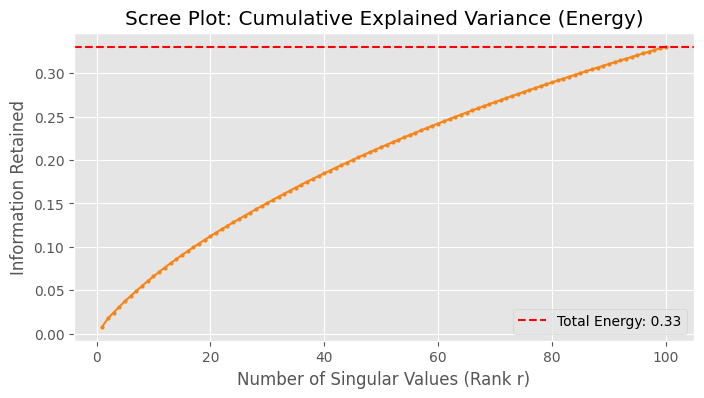

In [12]:
energy = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), energy, marker='o', markersize=2, color='#F58518')
plt.axhline(y=energy[-1], color='r', linestyle='--', label=f'Total Energy: {energy[-1]:.2f}')
plt.title("Scree Plot: Cumulative Explained Variance (Energy)")
plt.xlabel("Number of Singular Values (Rank r)")
plt.ylabel("Information Retained")
plt.legend()
plt.show()

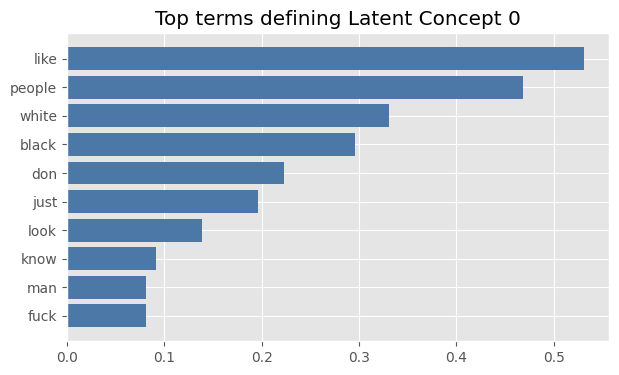

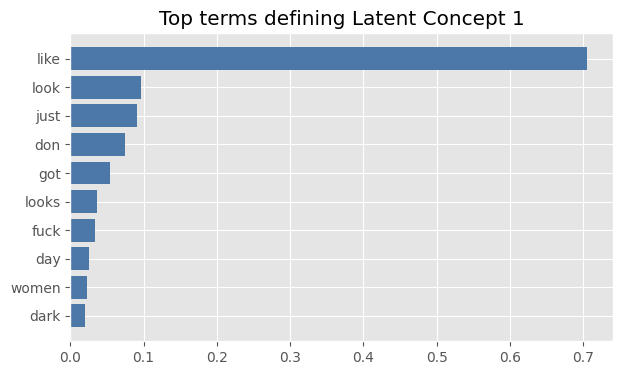

In [13]:
terms = vectorizer.get_feature_names_out()
for i in range(2): # Look at the first 2 concepts
    weights = svd.components_[i]
    top_indices = weights.argsort()[-10:][::-1]
    
    plt.figure(figsize=(7, 4))
    plt.barh([terms[idx] for idx in top_indices], weights[top_indices], color='#4C78A8')
    plt.title(f"Top terms defining Latent Concept {i}")
    plt.gca().invert_yaxis()
    plt.show()

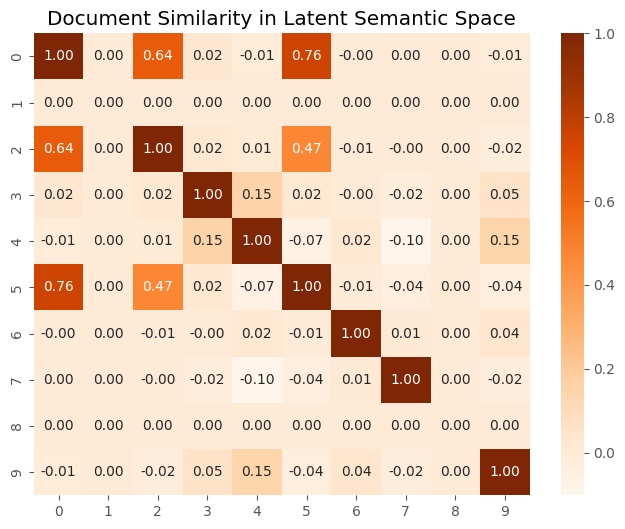

In [14]:
# Visualize similarity between first 10 validation memes
sample_sim = cosine_similarity(X_lsa_valid[:10])

plt.figure(figsize=(8, 6))
sns.heatmap(sample_sim, annot=True, cmap='Oranges', fmt=".2f")
plt.title("Document Similarity in Latent Semantic Space")
plt.show()

In [15]:
clf = LogisticRegression(max_iter=1000).fit(X_lsa_train, train['label'])
preds = clf.predict(X_lsa_valid)
acc_p1 = accuracy_score(valid['label'], preds)

print(f"Phase I (Text-only LSA) Baseline Accuracy: {acc_p1:.4f}")

Phase I (Text-only LSA) Baseline Accuracy: 0.5360


In [16]:
# Vectorize combined Text + Image Description
X_multi_tfidf_train = vectorizer.fit_transform(train['combined'])
X_multi_tfidf_valid = vectorizer.transform(valid['combined'])

# New SVD for Multimodal Shared Space
svd_m = TruncatedSVD(n_components=100, random_state=42)
X_multi_lsa_train = svd_m.fit_transform(X_multi_tfidf_train)
X_multi_lsa_valid = svd_m.transform(X_multi_tfidf_valid)

# Final Multimodal Classification
clf_m = LogisticRegression().fit(X_multi_lsa_train, train['label'])
acc_p2 = accuracy_score(valid['label'], clf_m.predict(X_multi_lsa_valid))

print(f"Phase II (Multimodal LSA) Accuracy: {acc_p2:.4f}")

Phase II (Multimodal LSA) Accuracy: 0.5420


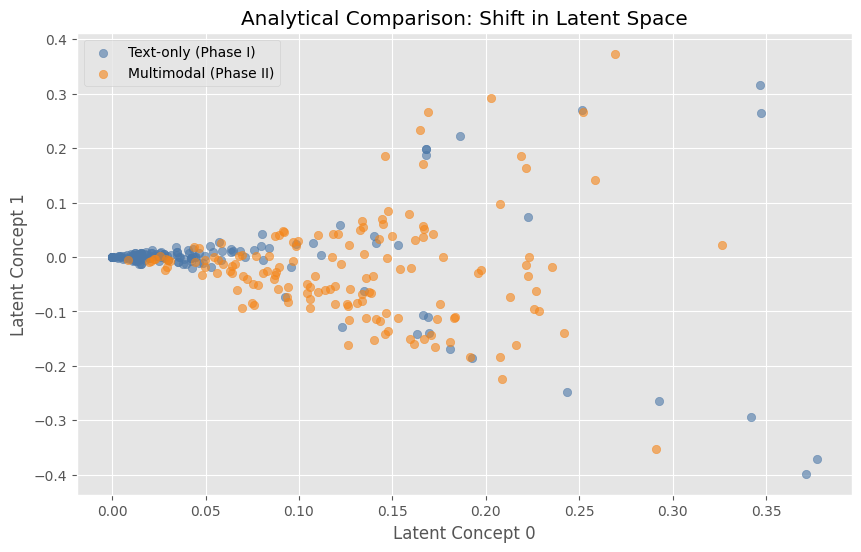

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(X_lsa_valid[:150, 0], X_lsa_valid[:150, 1], alpha=0.6, label='Text-only (Phase I)', c='#4C78A8')
plt.scatter(X_multi_lsa_valid[:150, 0], X_multi_lsa_valid[:150, 1], alpha=0.6, label='Multimodal (Phase II)', c='#F58518')

plt.title("Analytical Comparison: Shift in Latent Space")
plt.xlabel("Latent Concept 0")
plt.ylabel("Latent Concept 1")
plt.legend()
plt.show()

In [19]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Setup & Data Loading
df_merged = pd.read_csv('merged_dataset.csv')
df_desc = pd.read_csv('desc.csv')

# Merge datasets based on filename
df = pd.merge(df_merged, df_desc, on='filename', how='inner')

# Filter for train and valid splits
df = df[df['split'].isin(['train', 'valid'])].copy()

# Data Cleaning
df['text'] = df['text'].fillna('').astype(str)
df['desc'] = df['desc'].fillna('').astype(str)
df['label'] = df['label'].astype(int)

# Separate the splits
train_df = df[df['split'] == 'train']
valid_df = df[df['split'] == 'valid']

print(f"Dataset ready: {len(train_df)} training and {len(valid_df)} validation samples.\n")


# --- PHASE 1: TEXT-ONLY BASELINE ---
print("--- Running Phase 1: Text-only LSA ---")
vec_p1 = TfidfVectorizer(stop_words='english', max_features=1000, sublinear_tf=True)
X_train_tfidf_p1 = vec_p1.fit_transform(train_df['text'])
X_valid_tfidf_p1 = vec_p1.transform(valid_df['text'])

svd_p1 = TruncatedSVD(n_components=100, random_state=42)
X_train_lsa_p1 = svd_p1.fit_transform(X_train_tfidf_p1)
X_valid_lsa_p1 = svd_p1.transform(X_valid_tfidf_p1)

clf_p1 = LogisticRegression(max_iter=1000)
clf_p1.fit(X_train_lsa_p1, train_df['label'])
preds_p1 = clf_p1.predict(X_valid_lsa_p1)

# Generate Phase 1 Table
report_p1 = classification_report(valid_df['label'], preds_p1, output_dict=True)
df_report_p1 = pd.DataFrame(report_p1).transpose()

print("Phase 1 Detailed Metrics Table:")
print(df_report_p1.round(3).to_string())
print("-" * 30)


# --- PHASE 2: MULTIMODAL BASELINE ---
print("--- Running Phase 2: Multimodal LSA ---")
train_joint = train_df['text'] + " " + train_df['desc']
valid_joint = valid_df['text'] + " " + valid_df['desc']

vec_p2 = TfidfVectorizer(stop_words='english', max_features=1000, sublinear_tf=True)
X_train_tfidf_p2 = vec_p2.fit_transform(train_joint)
X_valid_tfidf_p2 = vec_p2.transform(valid_joint)

svd_p2 = TruncatedSVD(n_components=100, random_state=42)
X_train_lsa_p2 = svd_p2.fit_transform(X_train_tfidf_p2)
X_valid_lsa_p2 = svd_p2.transform(X_valid_tfidf_p2)

clf_p2 = LogisticRegression(max_iter=1000)
clf_p2.fit(X_train_lsa_p2, train_df['label'])
preds_p2 = clf_p2.predict(X_valid_lsa_p2)

# Generate Phase 2 Table
report_p2 = classification_report(valid_df['label'], preds_p2, output_dict=True)
df_report_p2 = pd.DataFrame(report_p2).transpose()

print("Phase 2 Detailed Metrics Table:")
print(df_report_p2.round(3).to_string())

Dataset ready: 8500 training and 500 validation samples.

--- Running Phase 1: Text-only LSA ---
Phase 1 Detailed Metrics Table:
              precision  recall  f1-score  support
0                 0.520   0.936     0.669  250.000
1                 0.680   0.136     0.227  250.000
accuracy          0.536   0.536     0.536    0.536
macro avg         0.600   0.536     0.448  500.000
weighted avg      0.600   0.536     0.448  500.000
------------------------------
--- Running Phase 2: Multimodal LSA ---
Phase 2 Detailed Metrics Table:
              precision  recall  f1-score  support
0                 0.523   0.952     0.675  250.000
1                 0.733   0.132     0.224  250.000
accuracy          0.542   0.542     0.542    0.542
macro avg         0.628   0.542     0.449  500.000
weighted avg      0.628   0.542     0.449  500.000
